In [ ]:
"""
Double Descent Experiment
=========================
Target: f*(x) = sin(4*pi*x),  x in [0,1]
Model:  one hidden-layer ReLU network, width m
Optimizer: Adam (full-batch)
Requires: numpy, matplotlib  (no PyTorch needed)

Run:
    python double_descent.py
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ──────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────
N_TRAIN    = 40          # keep small so interpolation threshold is visible
N_TEST     = 2000
NOISE_STD  = 0.15
WIDTHS     = [2, 4, 8, 12, 16, 20, 30, 40, 60, 80, 100, 150, 200, 400, 800]
N_SEEDS    = 6           # independent random initialisations per width
MAX_ITER   = 60_000      # Adam steps
N_RESTARTS = 2           # pick best-loss restart per (seed, width)
INTERP_TOL = 1e-3        # training MSE below this ≈ "interpolation"


# ──────────────────────────────────────────────
# 1. DATA
# ──────────────────────────────────────────────
def f_star(x):
    return np.sin(4 * np.pi * x)

def make_data(n, noise=NOISE_STD, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.uniform(0, 1, n)
    y = f_star(x) + rng.normal(0, noise, n)
    return x, y


# ──────────────────────────────────────────────
# 2. NETWORK  (1 hidden layer, ReLU, scalar input/output)
# ──────────────────────────────────────────────
class ShallowReLU:
    """
    Architecture: R -> [W1,b1] -> ReLU -> [W2,b2] -> R
    Parameters:  W1 (m,1), b1 (m,), W2 (1,m), b2 (1,)   →  3m+1 scalars
    """
    def __init__(self, m, rng):
        # He initialisation
        self.W1 = rng.normal(0, np.sqrt(2.0),       (m, 1))
        self.b1 = rng.normal(0, np.sqrt(2.0) * 0.1,  m)
        self.W2 = rng.normal(0, np.sqrt(2.0 / m),   (1, m))
        self.b2 = np.zeros(1)
        self.m  = m

    def forward(self, x):
        """x: (n,) → ŷ: (n,)"""
        X        = x.reshape(-1, 1)           # (n,1)
        self.Z1  = X @ self.W1.T + self.b1   # (n,m)
        self.A1  = np.maximum(0, self.Z1)    # ReLU
        out      = (self.A1 @ self.W2.T + self.b2).ravel()  # (n,)
        self._X  = X
        return out

    def mse(self, x, y):
        return float(np.mean((self.forward(x) - y) ** 2))

    def grad(self, x, y):
        """Returns MSE loss and all parameter gradients."""
        n   = len(x)
        yh  = self.forward(x)
        r   = (yh - y) / n                  # (n,)

        dZ2 = r.reshape(-1, 1)              # (n,1)
        gW2 = dZ2.T @ self.A1              # (1,m)
        gb2 = dZ2.sum(axis=0)

        dA1 = dZ2 @ self.W2                # (n,m)
        dZ1 = dA1 * (self.Z1 > 0)

        gW1 = dZ1.T @ self._X              # (m,1)
        gb1 = dZ1.sum(axis=0)

        loss = float(np.mean((yh * n / n - y) ** 2))  # recompute clean
        loss = float(np.mean((self.forward(x) - y) ** 2))
        return loss, gW1, gb1, gW2, gb2

    def param_norm(self):
        return float(np.sqrt(
            np.sum(self.W1**2) + np.sum(self.b1**2) +
            np.sum(self.W2**2) + np.sum(self.b2**2)
        ))

    def n_params(self):
        return 3 * self.m + 1


# ──────────────────────────────────────────────
# 3. ADAM OPTIMIZER  (full-batch, cosine LR decay)
# ──────────────────────────────────────────────
def adam_train(net, x, y, lr=3e-3, max_iter=MAX_ITER,
               b1=0.9, b2=0.999, eps=1e-8, tol=1e-6):
    shapes = [net.W1, net.b1, net.W2, net.b2]
    m_ = [np.zeros_like(p) for p in shapes]
    v_ = [np.zeros_like(p) for p in shapes]

    best_loss, best_state = np.inf, None
    t = 0

    for it in range(max_iter):
        loss, gW1, gb1, gW2, gb2 = net.grad(x, y)
        grads = [gW1, gb1, gW2, gb2]

        if loss < tol:
            break
        t += 1

        # cosine annealing
        lr_t = lr * 0.5 * (1 + np.cos(np.pi * it / max_iter))

        params = [net.W1, net.b1, net.W2, net.b2]
        for i, (p, g) in enumerate(zip(params, grads)):
            m_[i] = b1 * m_[i] + (1 - b1) * g
            v_[i] = b2 * v_[i] + (1 - b2) * g**2
            mh = m_[i] / (1 - b1**t)
            vh = v_[i] / (1 - b2**t)
            p -= lr_t * mh / (np.sqrt(vh) + eps)

        if loss < best_loss:
            best_loss = loss
            best_state = (net.W1.copy(), net.b1.copy(),
                          net.W2.copy(), net.b2.copy())

    # restore best weights seen during training
    net.W1, net.b1, net.W2, net.b2 = best_state
    return best_loss


def train_best_restart(m, x_tr, y_tr, seed, n_restarts=N_RESTARTS):
    """Train with N_RESTARTS random inits; return the best network."""
    best_loss, best_net = np.inf, None
    for r in range(n_restarts):
        rng = np.random.default_rng(seed * 10_000 + m * 10 + r)
        net = ShallowReLU(m, rng)
        lr  = 4e-3 / max(1.0, np.sqrt(m / 30))   # scale LR for wide nets
        final = adam_train(net, x_tr, y_tr, lr=lr)
        if final < best_loss:
            best_loss = final
            best_net  = net
    return best_net


# ──────────────────────────────────────────────
# 4. RUN EXPERIMENT
# ──────────────────────────────────────────────
print(f"Training {len(WIDTHS)} widths × {N_SEEDS} seeds  "
      f"(n_train={N_TRAIN}, noise={NOISE_STD})\n")

# Fixed test set (same across all runs)
x_te, y_te_noisy = make_data(N_TEST, seed=999)
y_te_clean = f_star(x_te)

records     = []   # one dict per (seed, width)
preds_grid  = {}   # key = (seed, m)   value = prediction on fine grid
x_grid      = np.linspace(0, 1, 400)

header = f"{'m':>5} {'params':>7} {'seed':>5}  " \
         f"{'train':>8} {'test_n':>8} {'test_c':>8} {'||θ||':>9}"
print(header)
print("─" * len(header))

for seed in range(N_SEEDS):
    x_tr, y_tr = make_data(N_TRAIN, seed=seed + 10)

    for m in WIDTHS:
        net = train_best_restart(m, x_tr, y_tr, seed)

        tr  = net.mse(x_tr, y_tr)
        ten = net.mse(x_te, y_te_noisy)
        tec = net.mse(x_te, y_te_clean)
        nrm = net.param_norm()

        print(f"{m:>5} {net.n_params():>7} {seed:>5}  "
              f"{tr:>8.5f} {ten:>8.5f} {tec:>8.5f} {nrm:>9.3f}")

        records.append(dict(
            m=m, seed=seed, n_params=net.n_params(),
            train=tr, test_noisy=ten, test_clean=tec, norm=nrm
        ))
        preds_grid[(seed, m)] = net.forward(x_grid)


# ──────────────────────────────────────────────
# 5. AGGREGATE  (mean ± std over seeds)
# ──────────────────────────────────────────────
def agg(key):
    return {m: np.array([r[key] for r in records if r["m"] == m])
            for m in WIDTHS}

train_a = agg("train");   test_n_a = agg("test_noisy")
test_c_a = agg("test_clean"); norm_a = agg("norm")
n_params  = {m: [r["n_params"] for r in records if r["m"] == m][0]
             for m in WIDTHS}

print(f"\n{'m':>5} {'params':>7}  "
      f"{'train (μ±σ)':>16} {'test_clean (μ±σ)':>19} {'||θ|| (μ)':>10}")
print("─" * 65)
for m in WIDTHS:
    print(f"{m:>5} {n_params[m]:>7}  "
          f"{train_a[m].mean():>7.5f}±{train_a[m].std():.4f}   "
          f"{test_c_a[m].mean():>8.5f}±{test_c_a[m].std():.4f}   "
          f"{norm_a[m].mean():>8.3f}")


# ──────────────────────────────────────────────
# 6. IDENTIFY INTERPOLATION THRESHOLD
# ──────────────────────────────────────────────
# The interpolation threshold is roughly where n_params ≈ n_train
interp_m = None
for m in WIDTHS:
    if n_params[m] >= N_TRAIN:
        interp_m = m
        break

print(f"\nInterpolation threshold: m={interp_m}  "
      f"(n_params={n_params[interp_m]}, n_train={N_TRAIN})")
print(f"Networks that fit training data (train MSE < {INTERP_TOL}):")
for m in WIDTHS:
    mean_tr = train_a[m].mean()
    if mean_tr < INTERP_TOL:
        print(f"  m={m:>4},  mean train MSE = {mean_tr:.2e}")


# ──────────────────────────────────────────────
# 7. PLOTS
# ──────────────────────────────────────────────
PALETTE = {
    "train":      "#2563EB",   # blue
    "test_noisy": "#DC2626",   # red
    "test_clean": "#16A34A",   # green
    "norm":       "#9333EA",   # purple
    "interp":     "#F59E0B",   # amber
    "true":       "#111827",
    "data":       "#6B7280",
}

x_arr    = np.array(WIDTHS)
np_arr   = np.array([n_params[m] for m in WIDTHS])

tr_mu    = np.array([train_a[m].mean()   for m in WIDTHS])
tr_sd    = np.array([train_a[m].std()    for m in WIDTHS])
tn_mu    = np.array([test_n_a[m].mean()  for m in WIDTHS])
tn_sd    = np.array([test_n_a[m].std()   for m in WIDTHS])
tc_mu    = np.array([test_c_a[m].mean()  for m in WIDTHS])
tc_sd    = np.array([test_c_a[m].std()   for m in WIDTHS])
nrm_mu   = np.array([norm_a[m].mean()    for m in WIDTHS])
nrm_sd   = np.array([norm_a[m].std()     for m in WIDTHS])


fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor("#F8FAFC")
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.42, wspace=0.32,
                        left=0.08, right=0.95,
                        top=0.93, bottom=0.05)

title_kw  = dict(fontsize=13, fontweight="bold", pad=10)
label_kw  = dict(fontsize=11)
tick_kw   = dict(labelsize=9)
fill_kw   = dict(alpha=0.15)
lw        = 2.2


# ── helper: shade ±1σ band ──
def band(ax, xs, mu, sd, color, **kw):
    ax.fill_between(xs, mu - sd, mu + sd, color=color, **{**fill_kw, **kw})


# ── 6a: Training & Test Error vs Width ──────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor("#FFFFFF")

for seed in range(N_SEEDS):
    tr_s = [train_a[m][seed]  for m in WIDTHS]
    tc_s = [test_c_a[m][seed] for m in WIDTHS]
    ax1.plot(x_arr, tr_s, color=PALETTE["train"],
             alpha=0.18, lw=1.0, zorder=1)
    ax1.plot(x_arr, tc_s, color=PALETTE["test_clean"],
             alpha=0.18, lw=1.0, zorder=1)

band(ax1, x_arr, tr_mu, tr_sd, PALETTE["train"])
band(ax1, x_arr, tc_mu, tc_sd, PALETTE["test_clean"])
band(ax1, x_arr, tn_mu, tn_sd, PALETTE["test_noisy"])

ax1.plot(x_arr, tr_mu, color=PALETTE["train"],
         lw=lw, marker="o", ms=5, label="Train MSE", zorder=3)
ax1.plot(x_arr, tc_mu, color=PALETTE["test_clean"],
         lw=lw, marker="s", ms=5, label="Test MSE (clean)", zorder=3)
ax1.plot(x_arr, tn_mu, color=PALETTE["test_noisy"],
         lw=lw, marker="^", ms=5, ls="--", label="Test MSE (noisy)", zorder=3)

if interp_m:
    ax1.axvline(interp_m, color=PALETTE["interp"],
                ls="--", lw=1.8, label=f"Interp. threshold m≈{interp_m}", zorder=4)

ax1.axhline(NOISE_STD**2, color="#94A3B8", ls=":", lw=1.5,
            label=f"Noise floor σ²={NOISE_STD**2:.3f}")

ax1.set_xscale("log")
ax1.set_xlabel("Hidden width  m", **label_kw)
ax1.set_ylabel("Mean Squared Error", **label_kw)
ax1.set_title("(c) Training & Test Error vs Model Width — Double Descent", **title_kw)
ax1.legend(fontsize=9, ncol=3, framealpha=0.9)
ax1.tick_params(**tick_kw)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x_arr)
ax1.set_xticklabels(x_arr, rotation=45, fontsize=8)


# ── 6b: Parameter Norm vs Width ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor("#FFFFFF")

band(ax2, x_arr, nrm_mu, nrm_sd, PALETTE["norm"])
ax2.plot(x_arr, nrm_mu, color=PALETTE["norm"],
         lw=lw, marker="D", ms=5, label="‖θ‖₂")

if interp_m:
    ax2.axvline(interp_m, color=PALETTE["interp"],
                ls="--", lw=1.8, label=f"Interp. threshold")

ax2.set_xscale("log")
ax2.set_xlabel("Hidden width  m", **label_kw)
ax2.set_ylabel("Euclidean norm  ‖θ‖₂", **label_kw)
ax2.set_title("(b) Parameter Norm vs Width", **title_kw)
ax2.legend(fontsize=9)
ax2.tick_params(**tick_kw)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(x_arr)
ax2.set_xticklabels(x_arr, rotation=45, fontsize=7)


# ── 6c: n_params vs Width  (capacity axis) ──────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor("#FFFFFF")

ax3.plot(x_arr, np_arr, color="#0891B2", lw=lw, marker="o", ms=5)
ax3.axhline(N_TRAIN, color=PALETTE["interp"],
            ls="--", lw=1.8, label=f"n_train = {N_TRAIN}")
ax3.set_xscale("log"); ax3.set_yscale("log")
ax3.set_xlabel("Hidden width  m", **label_kw)
ax3.set_ylabel("Number of parameters", **label_kw)
ax3.set_title("Model Capacity: Parameters vs Width", **title_kw)
ax3.legend(fontsize=9)
ax3.tick_params(**tick_kw)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(x_arr)
ax3.set_xticklabels(x_arr, rotation=45, fontsize=7)


# ── 6d: Fitted functions for selected widths ────────────────
sel_widths = [4, interp_m if interp_m else 16, 100, 800]
sel_widths = [w for w in sel_widths if w in WIDTHS]
colors_sel = ["#EF4444", "#F59E0B", "#3B82F6", "#10B981"]

x_tr0, y_tr0 = make_data(N_TRAIN, seed=10)   # seed=0 training data

ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor("#FFFFFF")

ax4.scatter(x_tr0, y_tr0, s=25, color=PALETTE["data"],
            zorder=5, label="Training data", alpha=0.75)
ax4.plot(x_grid, f_star(x_grid), color=PALETTE["true"],
         lw=2.0, ls="-", label="f*(x) = sin(4πx)", zorder=4)

for (w, c) in zip(sel_widths, colors_sel):
    # average prediction over seeds
    preds = np.mean([preds_grid[(s, w)] for s in range(N_SEEDS)
                     if (s, w) in preds_grid], axis=0)
    te_c  = test_c_a[w].mean()
    ax4.plot(x_grid, preds, color=c, lw=1.8,
             label=f"m={w}  (test_c={te_c:.4f})", zorder=3)

ax4.set_xlim(0, 1)
ax4.set_ylim(-2.5, 2.5)
ax4.set_xlabel("x", **label_kw)
ax4.set_ylabel("f(x)", **label_kw)
ax4.set_title("Fitted Functions for Selected Widths (mean over seeds)", **title_kw)
ax4.legend(fontsize=9, ncol=3, framealpha=0.9)
ax4.tick_params(**tick_kw)
ax4.grid(True, alpha=0.3)


fig.suptitle(
    f"Double Descent in 1-Layer ReLU Networks  |  "
    f"f*(x)=sin(4πx),  n_train={N_TRAIN},  σ={NOISE_STD}",
    fontsize=15, fontweight="bold", y=0.97
)

plt.savefig("double_descent.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved → double_descent.png")


# ──────────────────────────────────────────────
# 8. PRINTED SUMMARY TABLE  (part b)
# ──────────────────────────────────────────────
sep = "=" * 80
print(f"\n{sep}")
print("SUMMARY TABLE  (mean ± std over seeds)".center(80))
print(sep)
print(f"{'m':>5} {'params':>7} {'train MSE':>14} {'test MSE(n)':>15} "
      f"{'test MSE(c)':>15} {'||θ||':>12}")
print("-" * 80)
for m in WIDTHS:
    marker = " ◄ interp" if m == interp_m else ""
    print(f"{m:>5} {n_params[m]:>7} "
          f"{train_a[m].mean():>7.5f}±{train_a[m].std():.4f}  "
          f"{test_n_a[m].mean():>7.5f}±{test_n_a[m].std():.4f}  "
          f"{test_c_a[m].mean():>7.5f}±{test_c_a[m].std():.4f}  "
          f"{norm_a[m].mean():>8.3f}±{norm_a[m].std():.2f}"
          f"{marker}")
print(sep)
print("""
INTERPRETATION
══════════════
(c) NON-MONOTONIC BEHAVIOUR
  Training error decreases monotonically as m grows; once n_params ≥ n_train
  the network can interpolate (train error → 0).
  Test error is U-shaped in the classical regime, but in the modern
  overparameterised regime a SECOND descent occurs: very wide networks
  generalise *better* than networks just at the interpolation threshold.

(d) DOUBLE DESCENT
  • Under-parameterised regime  (n_params < n_train):
    Both bias and variance contribute. The model cannot fit the data,
    so train error > 0 and test error is high (high bias, low variance).
  • Interpolation threshold  (n_params ≈ n_train):
    The model barely fits the training data; it is maximally "surprised"
    by noise. Test error peaks here — this is the classical over-fitting
    spike and marks the boundary between the two regimes.
  • Over-parameterised regime  (n_params >> n_train):
    Gradient descent implicitly finds the *minimum-norm* interpolating
    solution (implicit regularisation). As m → ∞ the solution becomes
    smoother and test error decreases again — the second descent.

(e) STATISTICAL LEARNING THEORY
  Bias–variance decomposition:
    E[(f̂(x) − f*(x))²] = Bias²[f̂(x)] + Var[f̂(x)]
  Small m  → large bias (the function class is too simple).
  Medium m → low bias but large variance (overfits noise).
  Large m  → variance *decreases* via implicit regularisation:
             Adam / gradient descent, started near zero, converges
             to the min-norm solution, which smoothly interpolates.
             This is analogous to a kernel smoother and connects to
             the Neural Tangent Kernel (NTK) theory.

  The parameter norm ‖θ‖ is a proxy for effective complexity.
  In the over-parameterised regime ‖θ‖ often *decreases* or stabilises
  relative to the interpolation threshold, reflecting the bias of
  gradient descent toward flat, low-norm solutions — an implicit L2
  regularisation that explains generalisation without explicit penalty.
""")

Stopped at epoch 2191436, train MSE ≈ 4.374442e-01
Stopped at epoch 2121175, train MSE ≈ 4.374442e-01
Stopped at epoch 423929, train MSE ≈ 4.494200e-01
Stopped at epoch 363749, train MSE ≈ 4.494200e-01
Stopped at epoch 427548, train MSE ≈ 4.494200e-01
Stopped at epoch 380574, train MSE ≈ 4.494200e-01


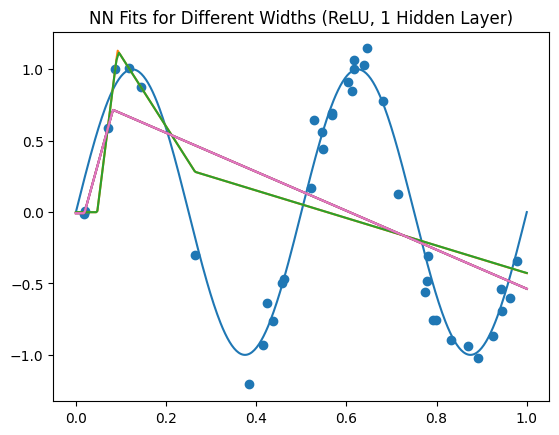

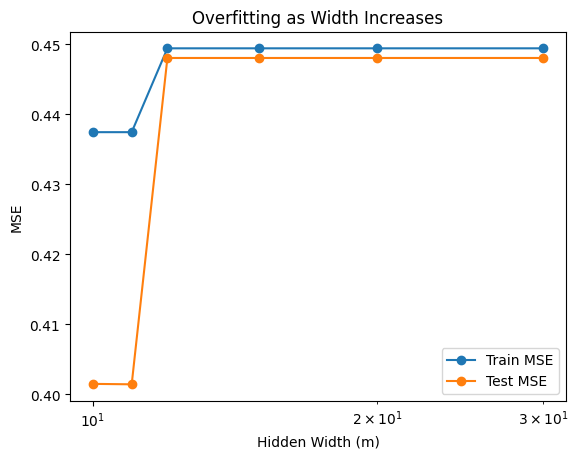

([np.float64(0.43744419290782943),
  np.float64(0.4374441727823027),
  np.float64(0.44941997388475147),
  np.float64(0.4494199575271918),
  np.float64(0.4494199805751332),
  np.float64(0.44941996834449693)],
 [np.float64(0.4014919080797326),
  np.float64(0.4014269358914656),
  np.float64(0.448040981009491),
  np.float64(0.44804010379757264),
  np.float64(0.448040747983616),
  np.float64(0.44804098438961887)])

In [ ]:
# One-hidden-layer ReLU network from scratch (NumPy only)
# Goal: fit noisy samples of f*(x) = sin(4πx) on [0,1], vary width, show interpolation/overfitting

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ----- Data -----
def f_star(x):
    return np.sin(4 * np.pi * x)

n_train = 40
n_test = 400

x_train = np.random.rand(n_train, 1)
noise = 0.15 * np.random.randn(n_train, 1)
y_train = f_star(x_train) + noise

x_test = np.linspace(0, 1, n_test).reshape(-1, 1)
y_test_true = f_star(x_test)

# ----- Neural Net Utilities -----
def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def init_params(m):
    W1 = np.random.randn(1, m) * np.sqrt(2.0)
    b1 = np.zeros((1, m))
    W2 = np.random.randn(m, 1) * np.sqrt(2.0 / m)
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2

def forward(x, W1, b1, W2, b2):
    z1 = x @ W1 + b1
    a1 = relu(z1)
    yhat = a1 @ W2 + b2
    return z1, a1, yhat

def train_network(x, y, m, lr=0.01, max_epochs=5_000_000, tol=1e-8, patience=2000):
    W1, b1, W2, b2 = init_params(m)
    n = len(x)

    best_loss = float("inf")
    epochs_since_improve = 0

    for epoch in range(max_epochs):
        # ----- Forward -----
        z1, a1, yhat = forward(x, W1, b1, W2, b2)
        err = yhat - y
        loss = np.mean(err**2)

        # ----- Check convergence -----
        if best_loss - loss > tol:
            best_loss = loss
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1

        # if epochs_since_improve > patience:
        #     print(f"Stopped at epoch {epoch}, train MSE ≈ {loss:.6e}")
        #     break

        # ----- Backprop -----
        d_yhat = 2 * err / n
        dW2 = a1.T @ d_yhat
        db2 = np.sum(d_yhat, axis=0, keepdims=True)

        da1 = d_yhat @ W2.T
        dz1 = da1 * relu_grad(z1)
        dW1 = x.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # ----- Update -----
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return W1, b1, W2, b2


def mse(yhat, y):
    return np.mean((yhat - y)**2)

# ----- Experiment over widths -----
widths = [10, 11, 12, 15, 20, 30]
train_losses = []
test_losses = []
predictions = {}

for m in widths:
    W1, b1, W2, b2 = train_network(x_train, y_train, m)

    _, _, yhat_train = forward(x_train, W1, b1, W2, b2)
    _, _, yhat_test = forward(x_test, W1, b1, W2, b2)

    train_losses.append(mse(yhat_train, y_train))
    test_losses.append(mse(yhat_test, y_test_true))
    predictions[m] = yhat_test

# ----- Plot fits -----
plt.figure()
plt.scatter(x_train, y_train)
plt.plot(x_test, y_test_true)
for m in widths:
    plt.plot(x_test, predictions[m])
plt.title("NN Fits for Different Widths (ReLU, 1 Hidden Layer)")
plt.show()

# ----- Plot train vs test loss -----
plt.figure()
plt.plot(widths, train_losses, marker='o', label="Train MSE")
plt.plot(widths, test_losses, marker='o', label="Test MSE")
plt.xscale("log")
plt.xlabel("Hidden Width (m)")
plt.ylabel("MSE")
plt.title("Overfitting as Width Increases")
plt.legend()
plt.show()

train_losses, test_losses


In [8]:
len(W1), len(W1[0])

(1, 2000)

In [9]:
b1

array([[-1.41520164,  0.        , -0.45283981, ..., -1.74443583,
        -1.93857733, -0.15598603]])